# Try to create a gaussian pulse in ccd
- then evaluate the crosstalk scaling when compared with rabi

- need to experiment with changing $\varepsilon$ and $\Omega$ concurrently - to keep the phase mod amplitude the same



In [18]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet

In [19]:
steel_blue, plum = "#4682B4", "#B44682"

## Create Gaussian Pulse Func

In [20]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0.48507178492998143*np.pi, rabi_freq/16, rabi_freq, -0.49999999968816566*np.pi


# Integration parameters
tol = 10**-5
evaluation_points = 2000
evaluation_time = 4/rabi_freq

In [21]:
def gaussian_root_x_ccd_epsilon(t, detuning):

    natural_freq = 10-detuning  # 10ghz   
    driving_freq = 10
    rabi_freq = 0.005

    phi_0 = 0.48507178492998143 * np.pi
    epsilon_m = rabi_freq / 16
    phase_freq = rabi_freq
    theta_m = -0.49999999968816566 * np.pi

    # Gaussian parameters
    pulse_length = 4 / rabi_freq
    centre = pulse_length / 2
    width = pulse_length / 4
    height = 0.008358656872801727

    # rabi_freq = height * np.exp(-((t - centre)**2) / (2 * width**2))
    epsilon_m = height * np.exp(-((t - centre)**2) / (2 * width**2))/16

    
    return {
        'natural_freq': natural_freq,
        'driving_freq': driving_freq,
        'rabi_freq': rabi_freq,
        'phi_0': phi_0,
        'epsilon_m': epsilon_m,
        'phase_freq': phase_freq,
        'theta_m': theta_m,
    }

In [22]:
def top_hat_root_x_ccd(t, detuning):

    natural_freq = 10  # 10ghz   
    driving_freq = 10
    rabi_freq = 0.005

    phi_0 = 0.48507178492998143 * np.pi
    epsilon_m = rabi_freq / 16
    phase_freq = rabi_freq
    theta_m = -0.49999999968816566 * np.pi

    # keeping ratio of epsilon_m to rabi_freq constant
    epsilon_m = rabi_freq / 16 
    return {
        'natural_freq': natural_freq-detuning,
        'driving_freq': driving_freq,
        'rabi_freq': rabi_freq,
        'phi_0': phi_0,
        'epsilon_m': epsilon_m,
        'phase_freq': phase_freq,
        'theta_m': theta_m,
    }

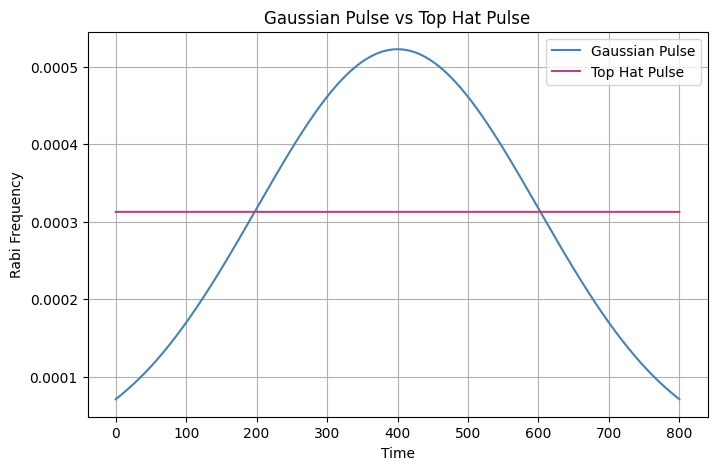

Gaussian Pulse Area: 0.2499840067376804
Top Hat Pulse Area: 0.25
The areas of the Gaussian and Top Hat pulses are not equal.


/var/folders/r1/4bsh28x136nb61xfvz5ly0dh0000gn/T/ipykernel_5904/3422278846.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gaussian_pulse_area = np.trapz(gauss_pulse_values, times)
/var/folders/r1/4bsh28x136nb61xfvz5ly0dh0000gn/T/ipykernel_5904/3422278846.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  top_hat_pulse_area = np.trapz(top_hat_pulse_values, times)


In [24]:
# create times
times = np.linspace(0, evaluation_time, evaluation_points)

# Generate pulse values over time using the top hat pulse function
top_hat_pulse_values = [top_hat_root_x_ccd(t, 0)['rabi_freq']/16 for t in times]
gauss_pulse_values = [gaussian_root_x_ccd_epsilon(t, 0)['epsilon_m'] for t in times]

# Plot the pulses
plt.figure(figsize=(8, 5))
plt.plot(times, gauss_pulse_values, label='Gaussian Pulse', color=steel_blue)
plt.plot(times, top_hat_pulse_values, label='Top Hat Pulse', color=plum)
plt.xlabel('Time')
plt.ylabel('Rabi Frequency')
plt.title('Gaussian Pulse vs Top Hat Pulse')
plt.legend()
plt.grid()
plt.show()

# Calculate the area of the Gaussian pulse
gaussian_pulse_area = np.trapz(gauss_pulse_values, times)

# Calculate the area of the Top Hat pulse
top_hat_pulse_area = np.trapz(top_hat_pulse_values, times)

# Print the areas
print(f"Gaussian Pulse Area: {gaussian_pulse_area}")
print(f"Top Hat Pulse Area: {top_hat_pulse_area}")

# Check if they are equal
if np.isclose(gaussian_pulse_area, top_hat_pulse_area):
    print("The areas of the Gaussian and Top Hat pulses are equal.")
else:
    print("The areas of the Gaussian and Top Hat pulses are not equal.")


## Run on CCD

In [ ]:
times, Us_driving_frame = qt.calculate_unitaries_pulse(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa, gaussian_root_x_ccd_epsilon, detuning=0)

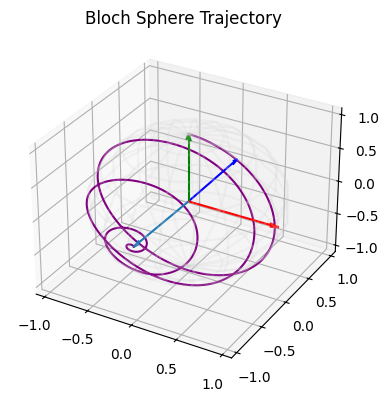

In [26]:
initial_state = np.array([1+0j,0+0j])

states = []
for U in Us_driving_frame:
    states.append(U @ initial_state)
states = np.array(states)

qt.visualise_solution(times, states)

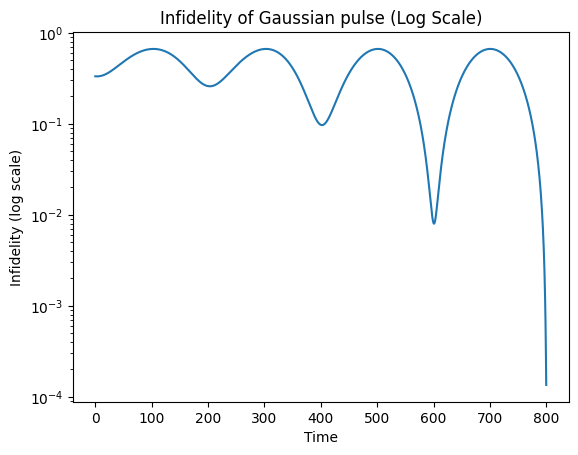

In [27]:
infids = 1 - qt.calculate_fidelities(root_x, Us_driving_frame, 2)

# Plot infidelity against time on a log scale
plt.figure()
plt.plot(times, infids)
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Infidelity (log scale)")
plt.title("Infidelity of Gaussian pulse (Log Scale)")
plt.show()

# Now look at the cross talk

### Gaussian

In [28]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0.48507178492998143*np.pi, rabi_freq/16, rabi_freq, -0.49999999968816566*np.pi


# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 4/rabi_freq

# iteration parameters
detunings = np.linspace(0, 40*rabi_freq, 1000)

fids_1 = []
fids_2 = []
fids_combined = []



# For each detuning, calculate fidelity for qubit 2 (identity gate)
for detuning in detunings:

    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries_pulse(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa, gaussian_root_x_ccd_epsilon, detuning=detuning)
    

    ccd_floquet_freq = np.sign(detuning)*2*ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m)[4]

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, ccd_floquet_freq, times)

    # Calculate fidelity for qubit 2 (identity gate)
    fid_2 = qt.calculate_fidelities(np.eye(2), transformed_Us, 2)
    fids_2.append(fid_2)
    


# Extract the final time step fidelity for each detuning
final_fids_2_ccd_gauss = [fid[-1] for fid in fids_2]

### Top Hat

In [29]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0.48507178492998143*np.pi, rabi_freq/16, rabi_freq, -0.49999999968816566*np.pi


# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 4/rabi_freq

# iteration parameters
detunings = np.linspace(0, 40*rabi_freq, 1000)

fids_1 = []
fids_2 = []
fids_combined = []



# For each detuning, calculate fidelity for qubit 2 (identity gate)
for detuning in detunings:

    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries_pulse(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa, top_hat_root_x_ccd, detuning=detuning)
    

    ccd_floquet_freq = np.sign(detuning)*2*ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m)[4]

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, ccd_floquet_freq, times)

    # Calculate fidelity for qubit 2 (identity gate)
    fid_2 = qt.calculate_fidelities(np.eye(2), transformed_Us, 2)
    fids_2.append(fid_2)
    


# Extract the final time step fidelity for each detuning
final_fids_2_ccd_top_hat = [fid[-1] for fid in fids_2]

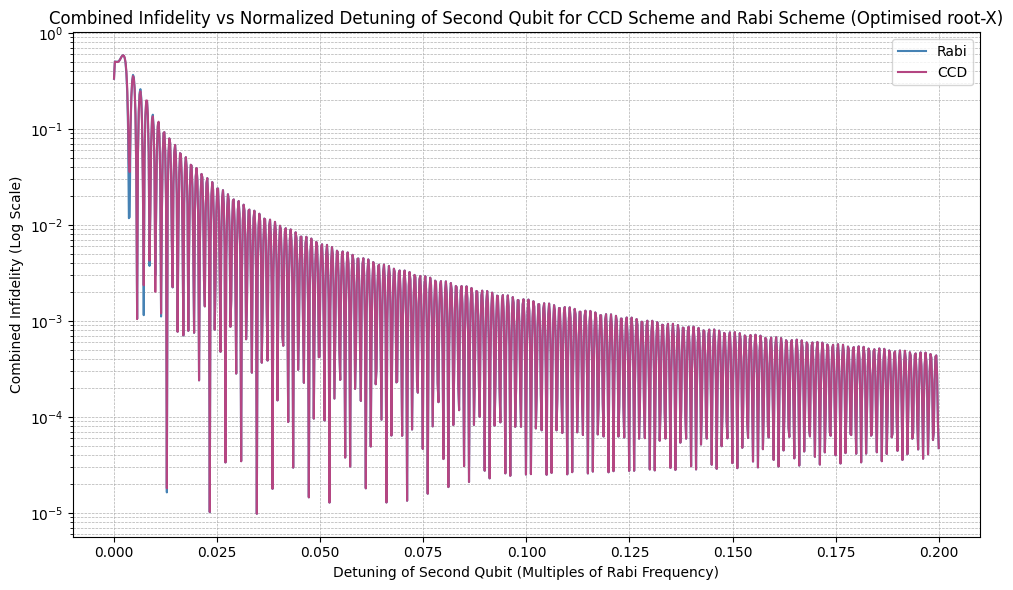

In [30]:
# find combdined infidelity
infidelities_2_ccd = 1-np.array(final_fids_2_ccd_gauss)
infidelities_2_rabi = 1-np.array(final_fids_2_ccd_top_hat)



# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings, infidelities_2_rabi, label="Rabi", color=steel_blue)
plt.semilogy(detunings, infidelities_2_ccd, label="CCD", color=plum)

plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency)")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Normalized Detuning of Second Qubit for CCD Scheme and Rabi Scheme (Optimised root-X)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
#plt.savefig("dirty_root_x_scaling.png", dpi=300)
plt.show()



hmmmmm - so it is the omega that counts?? there is a slight difference here
so I need to do something to get the omega in a gaussian shape 

# another attempt
- try tracking epsilon and phase freq with a gaussian rabi freq
- if that fails I may need to do optimisiation to get a rootx with gauss

In [75]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0.48507178492998143*np.pi, rabi_freq/16, rabi_freq, -0.49999999968816566*np.pi


# Integration parameters
tol = 10**-5
evaluation_points = 2000
evaluation_time = 4/rabi_freq

In [ ]:
def gaussian_root_x_ccd(t, detuning):

    natural_freq = 10-detuning  # 10ghz   
    driving_freq = 10
    rabi_freq = 0.005

    phi_0 = 0.48507178492998143 * np.pi
    epsilon_m = rabi_freq / 16
    phase_freq = rabi_freq
    theta_m = -0.49999999968816566 * np.pi

    # Gaussian parameters
    pulse_length = 4 / rabi_freq
    centre = pulse_length / 2
    width = pulse_length / 4
    height = 0.008358656872801727

    rabi_freq = height * np.exp(-((t - centre)**2) / (2 * width**2))
    epsilon_m = height * np.exp(-((t - centre)**2) / (2 * width**2))/16
    
    
    return {
        'natural_freq': natural_freq,
        'driving_freq': driving_freq,
        'rabi_freq': rabi_freq,
        'phi_0': phi_0,
        'epsilon_m': epsilon_m,
        'phase_freq': phase_freq,
        'theta_m': theta_m,
    }

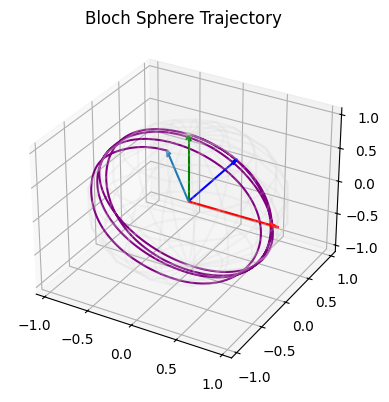

In [123]:
times, Us_gauss = qt.calculate_unitaries_pulse(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa, gaussian_root_x_ccd, detuning=0)
initial_state = np.array([1+0j,0+0j])

states = []
for U in Us_gauss:
    states.append(U @ initial_state)
states = np.array(states)

qt.visualise_solution(times, states)


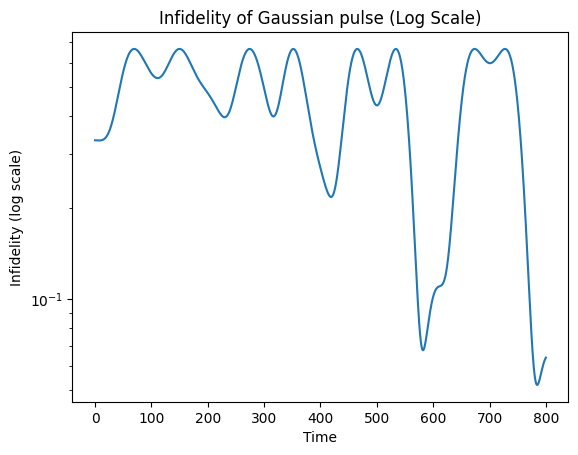

In [113]:
infids = 1 - qt.calculate_fidelities(root_x, Us_gauss, 2)

# Plot infidelity against time on a log scale
plt.figure()
plt.plot(times, infids)
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Infidelity (log scale)")
plt.title("Infidelity of Gaussian pulse (Log Scale)")
plt.show()

In [84]:
gauss_pulse_values = [gaussian_root_x_ccd(t, 0)['epsilon_m'] for t in times]
print(np.trapz(gauss_pulse_values, times))

0.1495359903761001


/var/folders/r1/4bsh28x136nb61xfvz5ly0dh0000gn/T/ipykernel_5904/3374580879.py:2: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(np.trapz(gauss_pulse_values, times))
